# Detecting balls in an image 🎱

This Jupyter Notebook show a way to detect balls in a image and your color.

In [3]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load data
The images to test the model is in `datas/`

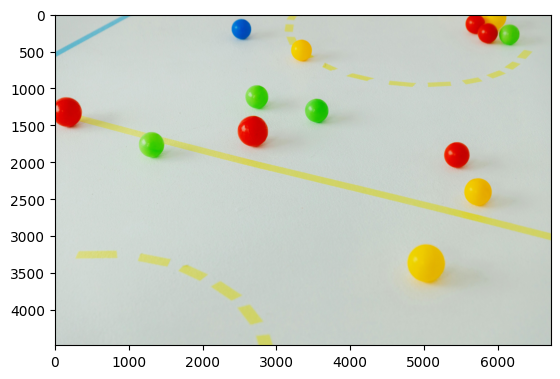

In [2]:
im = cv2.imread('datas/balls-test.jpg')
im_RGB = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im_RGB);

## Detecting the ball

First we need to process the image
- Change the scale BRG into GRAY
- Appling a filter to best resolution

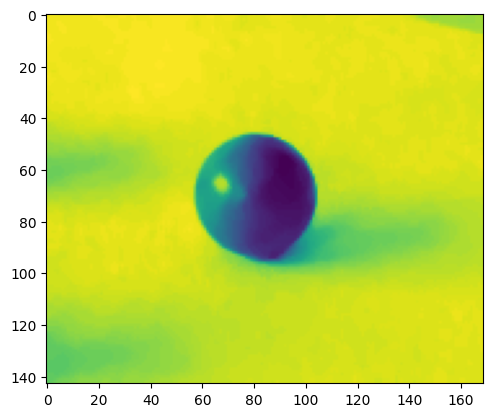

In [83]:
# read the image 
img = cv2.imread('datas/one-green-ball.jpg')

# transform the img in gray-scale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# applying filtes in the image
img_gray = cv2.medianBlur(img_gray, 5)
plt.imshow(img_gray);

The `openCV` has a function to find all circles on the image, you sintax is:\
`cv2.HoughCircles`(img_input, method_detection, [params])

- `dp`: Resolution of the accumulator image.
- `minDist`: Minimum distance between the centers of the circles.
- `param1`: Upper threshold for the Canny edge detector.
- `param2`: Threshold for detecting circles.
- `minRadius`: Minimum radius of the circles.
- `maxRadius`: Maximum radius of the circles

In [26]:
# use the function to found circles on the image
circles = cv2.HoughCircles(img_gray, cv2.HOUGH_GRADIENT, dp=1, minDist=20,
                            param1=50,param2=30,minRadius=0,maxRadius=0)

After found the circles on the image, we write on the image to visualize the model predict

In [33]:
# Draw the circles on the image
circles = np.uint16(np.around(circles))
for i in circles[0,:]:
    # cordenates of the circle
    x, y, r = i[0], i[1], i[2]
    
    # draw the outer circle
    cv2.circle(img,(i[0],i[1]),i[2],(0,255,0),2)
    # draw the center of the circle
    cv2.circle(img,(i[0],i[1]),2,(0,0,255),3)

    # change the image in HSV
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Extracting the mean color
    mask = np.zeros(img_hsv.shape[:2], dtype=np.uint8)
    # create the mask
    cv2.circle(mask, (x, y), r, 255, thickness=-1)
    
    # calculate the medium color
    mean_colour_hsv = cv2.mean(img_hsv, mask=mask)[:3]

    img_colour = identify_colour(mean_colour_hsv)
    print('The color is', img_colour)

The color is Verde


Shows the Image with circle spotted

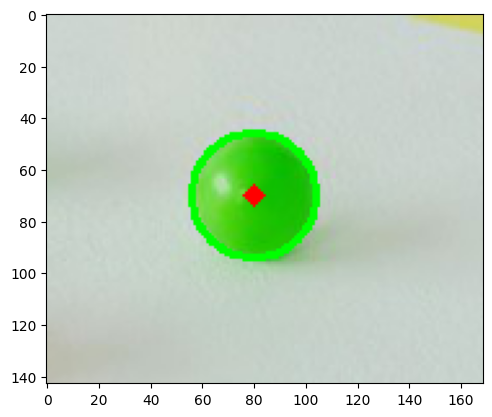

In [20]:
# show the image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB));

We got to find the circle on the image, now we create a function to become more easy the identif of the balls

In [4]:
def identify_colour(hsv_colour):
    """
    Identifies the dominant color based on the average HSV value.

    Parameters:
    hsv_colour (tuple): A tuple (h, s, v) representing the hue, 
                        saturation, and value of the color.

    Returns:
    str: The detected color name among Black, Gray, White, Red, 
         Yellow, Green, Blue, or "Unknown".
    """
    h, s, v = hsv_colour

    if v < 50:
        return "Black"
    elif s < 50 and 50 <= v < 200:
        return "Grey"
    elif s < 50 and v >= 200:
        return "White"
    elif (0 <= h <= 10) or (170 <= h <= 180):
        return "Red"
    elif 25 <= h <= 35:
        return "Yellow"
    elif 35 <= h <= 85:
        return "Green"
    elif 100 <= h <= 130:
        return "Blue"
    else:
        return "Unknown"

In [65]:
def find_ball(img):
    """
    Detects circles (balls) in an image and highlights them.

    Parameters:
    img (numpy.ndarray): Image loaded with cv2.imread.

    Returns:
    numpy.ndarray: The processed image with detected circles outlined 
                   and their identified colors labeled.
    """

    # resize the image into dimensions ESP32-cam
    desired_width = 320
    desired_height = 240
    dim = (desired_width, desired_height)
    img = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)

    # to de
    print(img.shape)
    # transform the img in gray-scale
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # applying filtes in the image
    img_gray = cv2.medianBlur(img_gray, 5)

    # use the function to found circles on the image
    circles = cv2.HoughCircles(img_gray, cv2.HOUGH_GRADIENT, dp=1.5, minDist=40,
                           param1=60, param2=30, minRadius=5, maxRadius=60)

    # verify if has circles on the image
    if circles is not None: 
        circles = np.uint16(np.around(circles))
        for i in circles[0,:]:
            # cordenates of the circle
            x, y, r = i[0], i[1], i[2]
            
            # draw the outer circle
            cv2.circle(img,(i[0],i[1]),i[2],(0,255,0),2)
            # draw the center of the circle
            cv2.circle(img,(i[0],i[1]),2,(0,0,255),3)
        
            # change the image in HSV
            img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            
            # Extracting the mean color
            mask = np.zeros(img_hsv.shape[:2], dtype=np.uint8)
            # create the mask
            cv2.circle(mask, (x, y), r, 255, thickness=-1)
            
            # calculate the medium color
            mean_colour_hsv = cv2.mean(img_hsv, mask=mask)[:3]
    
            # get the color of the object
            img_colour = identify_colour(mean_colour_hsv)
            
            text_position = (x - 10, y - r - 10)
            # writing the colour on the image
            cv2.putText(img, img_colour, text_position, 
                        fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.6, 
                        color=(0, 255, 0), thickness=1, 
                        lineType=cv2.LINE_AA) 

    return img

(204, 217, 3)


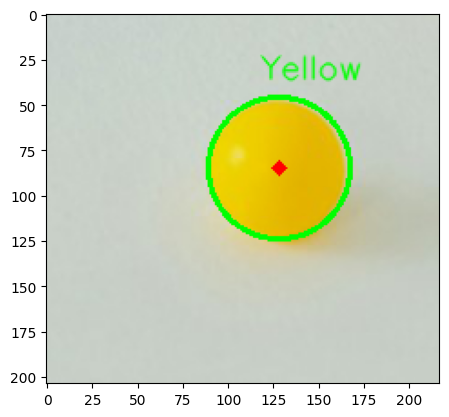

In [61]:
img = cv2.imread('datas/one-yellow-ball.jpg')
img_detected = find_ball(img)

plt.imshow(cv2.cvtColor(img_detected, cv2.COLOR_BGR2RGB));

(143, 169, 3)


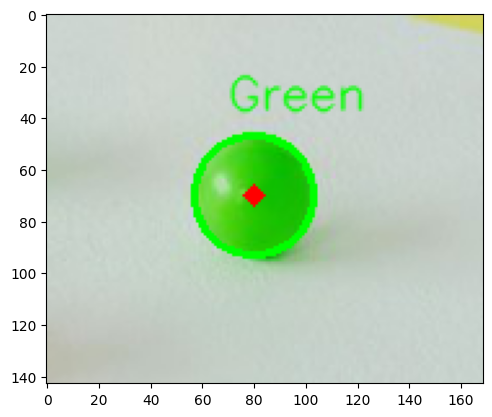

In [60]:
img = cv2.imread('datas/one-green-ball.jpg')
img_detected = find_ball(img)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB));

(240, 320, 3)


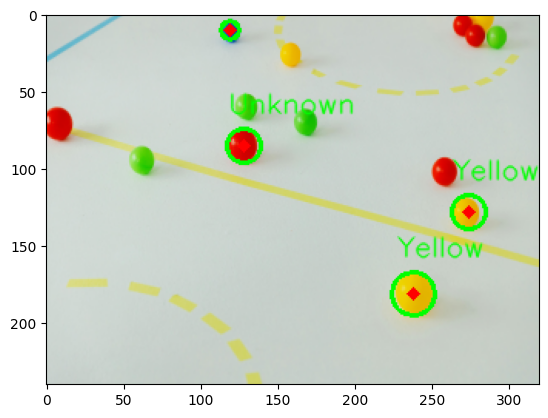

In [32]:
img = cv2.imread('datas/balls-test.jpg')
img_detected = find_ball(img)

plt.imshow(cv2.cvtColor(img_detected, cv2.COLOR_BGR2RGB));

(240, 320, 3)


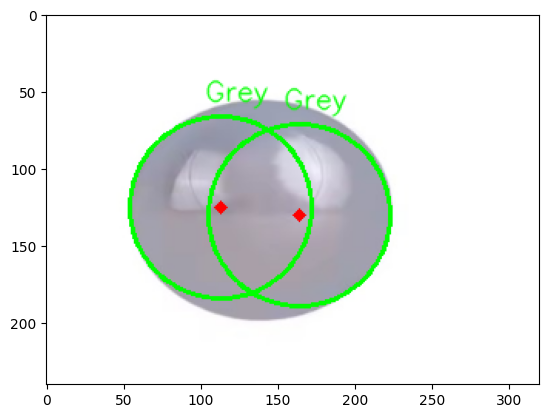

In [66]:
img = cv2.imread('datas/one-grey-ball.jpg')
if img is not None:
    img_detected = find_ball(img)
    
    plt.imshow(cv2.cvtColor(img_detected, cv2.COLOR_BGR2RGB));
else:
    print('error opening the image')

We can see the models runs good, we need only to change the parms on `HoughCircles` to detect the circles in the best way